<a href="https://colab.research.google.com/github/junsookim76/Ewha_2026/blob/main/rdkit_to_qspr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분자를 다루는 딥러닝 — RDKit부터 QSPR까지

여러분은 이미 다층 퍼셉트론(MLP) 같은 딥러닝의 기초를 알고 있습니다. 그런데 입력이 이미지나 표가 아니라 **분자(molecule)** 라면 어떻게 신경망에 넣을까요?

오늘의 핵심 질문은 단 하나입니다.

> ### "분자를 어떻게 숫자로 바꿔서 신경망에 먹일 것인가?"

이 질문을 따라 네 단계로 진행합니다.

| 파트 | 내용 | 시간 |
|------|------|------|
| **1** | 분자를 불러오고 그리기 (SMILES → 2D/3D) | ~22분 |
| **2** | 구조를 숫자로 — 분자 디스크립터 | ~18분 |
| **3** | 특징 공간 둘러보기 — 상관분석 & PCA | ~12분 |
| **4** | 진짜 물성 예측하기 — 녹는점 QSPR | ~23분 |
| | 마무리 & 다음 단계 | ~5분 |

> **QSPR** = Quantitative Structure–Property Relationship (정량적 구조-물성 관계). 분자의 구조에서 물성을 예측하는 일.


## 0. 환경 설정

아래 셀을 **가장 먼저** 한 번 실행하세요.

> ⚠️ **중요:** `mordred`는 numpy 2.x에서 깨집니다(`from numpy import product` 오류). 그래서 numpy를 1.x로 내립니다. 설치가 끝나면 Colab이 **"세션 다시 시작(Restart runtime)"** 을 요구합니다 → **반드시 재시작**한 뒤, 이 셀은 건너뛰고 다음 셀부터 이어서 실행하세요. (재시작은 한 번만 하면 됩니다.)

In [ ]:
!pip install rdkit mordred seaborn py3Dmol
# mordred는 numpy 2.x에서 깨지므로 1.x로 고정 (설치 후 런타임 재시작 필요)
!pip install "numpy<2"

---
# 파트 1. 분자를 불러오고 그리기  (~22분)

분자를 컴퓨터에 입력하는 가장 흔한 방법은 **SMILES** 라는 문자열입니다.

> **SMILES** ( Simplified Molecular Input Line Entry System )
>
> - `C` : 탄소 (수소는 자동으로 채워짐)
> - `=` : 이중결합,  `#` : 삼중결합
> - `()` : 가지(branch)
> - `c` (소문자) : 방향족 탄소
>
> | 분자 | 화학식 | SMILES |
> |------|--------|--------|
> | 에탄올 | C₂H₆O | `CCO` |
> | 아세톤 | C₃H₆O | `CC(=O)C` |
> | 아세트산 | C₂H₄O₂ | `CC(=O)O` |
> | 벤젠 | C₆H₆ | `c1ccccc1` |

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.ipython_useSVG = True

`Chem.MolFromSmiles()` 가 SMILES 문자열을 RDKit 분자 객체로 바꿉니다. 노트북에서 객체를 그대로 출력하면 구조가 그려집니다.

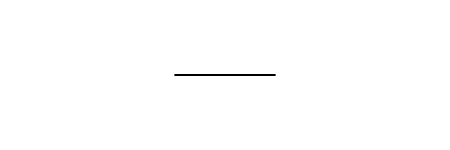

In [ ]:
# 가장 간단한 예: 에테인 (C-C)
m1 = Chem.MolFromSmiles('CC')
m1

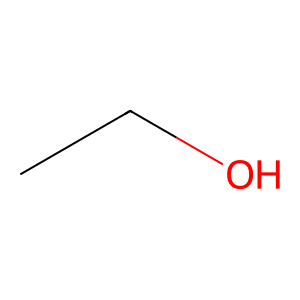

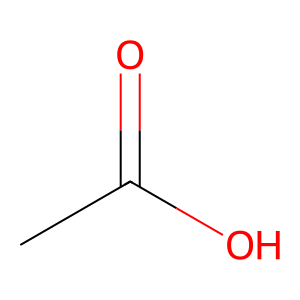

In [ ]:
ethanol     = Chem.MolFromSmiles('CCO')
acetic_acid = Chem.MolFromSmiles('CC(=O)O')

display(Draw.MolToImage(ethanol))
display(Draw.MolToImage(acetic_acid))

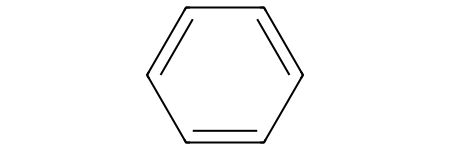

In [ ]:
# 방향족 고리: 소문자 c
benzene = Chem.MolFromSmiles('c1ccccc1')
benzene

### <font color=crimson>실습 1</font>
> (a) 아세톤(acetone)의 SMILES로 분자 구조를 그려보세요.
>
> (b) 페놀(phenol)의 SMILES로 분자 구조를 그려보세요.
>
> *힌트: 아세톤 `CC(=O)C`, 페놀 `c1ccccc1O`*

In [ ]:
# 실습 1 — 여기에 작성해 보세요



## 분자 안을 들여다보기 — 원자와 결합

분자 객체는 원자(atom)와 결합(bond)의 모음입니다. 아스피린을 예로 하나씩 꺼내봅니다.

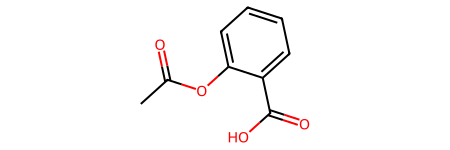

In [ ]:
aspirin = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
aspirin

In [ ]:
print("원자 수:", aspirin.GetNumAtoms())
print("결합 수:", aspirin.GetNumBonds())

원자 수: 13
결합 수: 13


In [ ]:
for atom in aspirin.GetAtoms():
    print(f"원자 번호: {atom.GetIdx():2d}, 원자 기호: {atom.GetSymbol()}")

원자 번호:  0, 원자 기호: C
원자 번호:  1, 원자 기호: C
원자 번호:  2, 원자 기호: O
원자 번호:  3, 원자 기호: O
원자 번호:  4, 원자 기호: C
원자 번호:  5, 원자 기호: C
원자 번호:  6, 원자 기호: C
원자 번호:  7, 원자 기호: C
원자 번호:  8, 원자 기호: C
원자 번호:  9, 원자 기호: C
원자 번호: 10, 원자 기호: C
원자 번호: 11, 원자 기호: O
원자 번호: 12, 원자 기호: O


In [ ]:
for bond in aspirin.GetBonds():
    print(f"결합 번호: {bond.GetIdx():2d}, 결합 타입: {bond.GetBondType()}")

결합 번호:  0, 결합 타입: SINGLE
결합 번호:  1, 결합 타입: DOUBLE
결합 번호:  2, 결합 타입: SINGLE
결합 번호:  3, 결합 타입: SINGLE
결합 번호:  4, 결합 타입: AROMATIC
결합 번호:  5, 결합 타입: AROMATIC
결합 번호:  6, 결합 타입: AROMATIC
결합 번호:  7, 결합 타입: AROMATIC
결합 번호:  8, 결합 타입: AROMATIC
결합 번호:  9, 결합 타입: SINGLE
결합 번호: 10, 결합 타입: DOUBLE
결합 번호: 11, 결합 타입: SINGLE
결합 번호: 12, 결합 타입: AROMATIC


## 2D에서 3D로

SMILES는 평면(2D) 정보만 담고 있습니다. 3D 구조가 필요하면 (1) 수소를 명시적으로 붙이고, (2) 3D 좌표를 생성한 뒤, (3) 힘장(force field)으로 에너지를 최소화합니다.

In [ ]:
from rdkit.Chem import AllChem

mol3d = Chem.AddHs(Chem.MolFromSmiles('C1CC1O'))   # 사이클로프로판올 + 수소 추가
AllChem.EmbedMolecule(mol3d)                       # 3D 좌표 생성
AllChem.UFFOptimizeMolecule(mol3d)                 # UFF로 구조 최적화

print("3D 좌표인가?", mol3d.GetConformer().Is3D())

3D 좌표인가? True


`py3Dmol` 로 3D 구조를 마우스로 돌려볼 수 있습니다.

In [ ]:
!pip install py3Dmol
import py3Dmol

mb = Chem.MolToMolBlock(mol3d)

view = py3Dmol.view(width=500, height=500)
view.addModel(mb, 'mol')
view.setStyle({'stick': {}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### <font color=crimson>실습 2</font>
> 아세톤(`CC(=O)C`)의 3차원 구조를 생성하고 py3Dmol로 회전시켜 보세요.
>
> *(참고: PubChem(https://pubchem.ncbi.nlm.nih.gov)에서 실제 측정/계산된 3D 구조를 SDF로 내려받아 `Chem.MolFromMolBlock`으로 읽을 수도 있습니다.)*

In [ ]:
# 실습 2 — 여기에 작성해 보세요



---
# 파트 2. 구조를 숫자로 — 분자 디스크립터  (~18분)

신경망은 그림이나 그래프를 그대로 먹지 못합니다. 분자를 **고정된 길이의 숫자 벡터**로 바꿔야 하는데, 이 숫자들을 **디스크립터(descriptor)** 라고 합니다. (분자량, 방향족 원자 수, 극성도 등)

먼저 여러 분자를 한꺼번에 다뤄봅니다. ChEMBL(약물 유사 분자 데이터베이스)에서 추린 작은 SMILES 세트를 불러옵니다.

In [ ]:
!git clone https://github.com/junsookim76/Ewha_2026.git

Cloning into 'Ewha_2026'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 132 (delta 67), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 3.79 MiB | 5.95 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [ ]:
import numpy as np
import pandas as pd

mols = []
with open("./Ewha_2026/chembl_mini.smi") as f:
    for line in f:
        data = line.split()
        mol  = Chem.MolFromSmiles(data[0])
        mol.SetProp("chembl_id", data[1])
        mol.SetProp("smiles", data[0])
        mols.append(mol)

print("불러온 분자 수:", len(mols))

불러온 분자 수: 5000


In [ ]:
df = pd.DataFrame([{
    "chembl_id": m.GetProp("chembl_id"),
    "smiles":    m.GetProp("smiles")
} for m in mols])
df.head()

,chembl_id,smiles
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C
1,CHEMBL503634,COc1c(O)cc(O)c(C(=N)Cc2ccc(O)cc2)c1O
2,CHEMBL503643,CCOC(=O)c1cc2cc(C(=O)O)ccc2[nH]1
3,CHEMBL155287,O=C(NO)c1ccc(I)cc1
4,CHEMBL265174,C=CCc1ccc(OC(=O)C23CC4CC(CC(C4)C2)C3)c(OC)c1


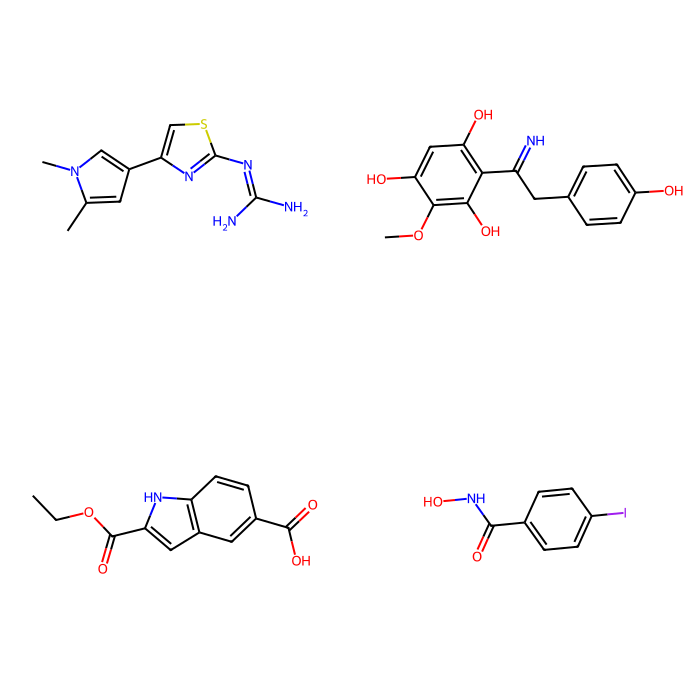

In [ ]:
# 여러 분자를 격자로 한눈에
Draw.MolsToGridImage(mols[:4], molsPerRow=2, subImgSize=(350, 350))

## 디스크립터 계산 — Mordred

[Mordred](https://mordred-descriptor.github.io)는 수천 종의 디스크립터를 계산할 수 있습니다. 여기서는 속도를 위해 대표적인 몇 종류만 등록합니다.

In [ ]:
from mordred import Calculator, descriptors

calc = Calculator(descriptors.ABCIndex)
for d in [descriptors.AcidBase, descriptors.Aromatic, descriptors.AtomCount,
          descriptors.BondCount, descriptors.BalabanJ, descriptors.HydrogenBond,
          descriptors.Polarizability, descriptors.WalkCount, descriptors.Weight,
          descriptors.TopologicalCharge]:
    calc.register(d)

print("등록된 디스크립터 수:", len(calc.descriptors))

등록된 디스크립터 수: 81


In [ ]:
mordred = calc.pandas(mols)   # 각 분자 = 한 행, 각 디스크립터 = 한 열
mordred

100%|██████████| 5000/5000 [00:59<00:00, 84.26it/s] 


,ABC,ABCGG,nAcid,nBase,nAromAtom,nAromBond,nAtom,nHeavyAtom,nSpiro,nBridgehead,...,JGI2,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,JGT10
0,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,3,10,10,29,16,0,0,...,0.074074,0.066520,0.048235,0.025481,0.032993,0.012915,0.026878,0.000000,0.000000,0.551803
1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,12,12,36,21,0,0,...,0.093190,0.068015,0.048315,0.037879,0.018442,0.014853,0.016683,0.008563,0.017524,0.550736
2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,1,0,9,10,28,17,0,0,...,0.088889,0.051215,0.050917,0.030174,0.027647,0.020727,0.011519,0.013333,0.000000,0.516643
3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,6,6,17,11,0,0,...,0.111111,0.038462,0.047778,0.052778,0.026939,0.000000,0.000000,0.000000,0.000000,0.504340
4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,6,6,50,24,0,4,...,0.061111,0.046875,0.045657,0.031713,0.011398,0.015224,0.011074,0.009777,0.006870,0.498958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,11,11,30,18,0,0,...,0.082305,0.021991,0.022722,0.029965,0.028976,0.007653,0.005393,0.008662,0.009437,0.367104
4996,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,11,11,44,21,0,0,...,0.101587,0.071128,0.049706,0.055556,0.016296,0.031308,0.000000,0.000000,0.000000,0.689217
4997,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,18,18,45,25,0,0,...,0.087719,0.051829,0.042339,0.034127,0.019784,0.013125,0.013192,0.008047,0.006806,0.462153
4998,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,0,0,18,18,43,26,0,0,...,0.085470,0.041667,0.045497,0.035119,0.019712,0.014509,0.014823,0.006424,0.005669,0.465318


이제 각 분자가 **숫자 벡터 한 줄**이 되었습니다. 이 표가 바로 신경망의 입력입니다. 예를 들어 `AMW`(평균 분자량) 열은 이렇게 꺼냅니다.

In [ ]:
mordred['AMW']

,AMW
0,8.106523
1,8.030417
2,8.323886
3,15.467313
4,6.523764
...,...
4995,8.003370
4996,6.935368
4997,7.824740
4998,8.444021


---
# 파트 3. 특징 공간 둘러보기 — 상관분석 & PCA  (~12분)

디스크립터끼리는 서로 많이 겹칩니다(상관관계가 높음). 얼마나 겹치는지, 그리고 수십 개의 축을 2개로 압축하면 데이터가 어떻게 보이는지 살펴봅니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46356 (\N{HANGUL SYLLABLE DI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

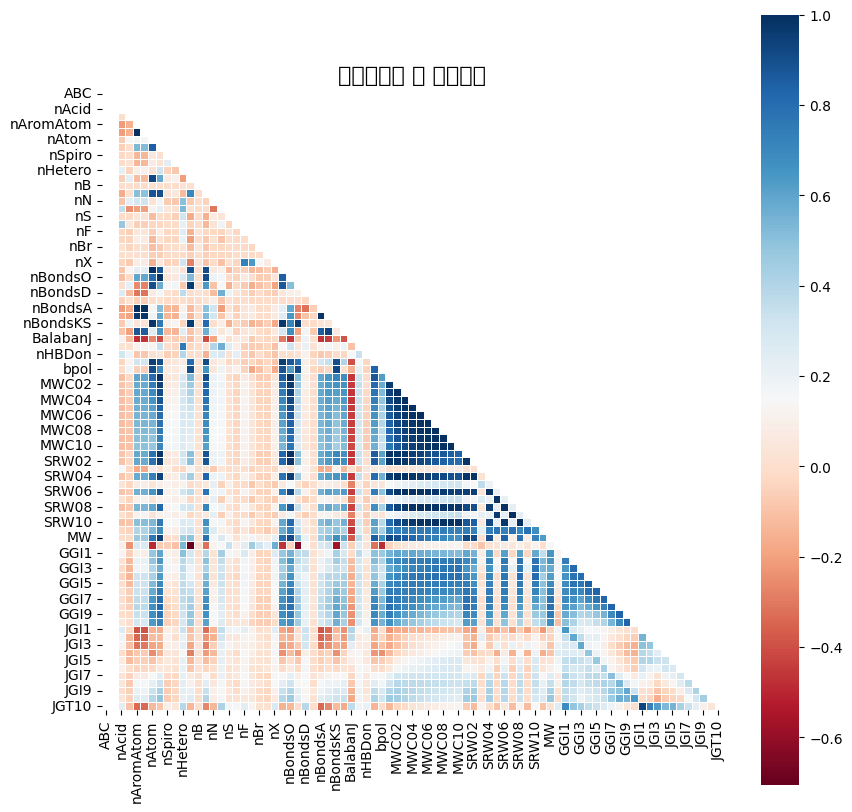

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation = mordred.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(correlation, mask=mask, cmap="RdBu", square=True, linewidths=0.5)
plt.title("디스크립터 간 상관관계", fontsize=16)
plt.show()

In [ ]:
mordred.corr().shape

(81, 81)

## PCA — 수십 개 축을 2개로

> **PCA (주성분 분석)**: 정보(분산)를 최대한 보존하면서 차원을 줄입니다.
> - **PC1**: 데이터가 가장 크게 변하는 방향
> - **PC2**: PC1과 직교하면서 그다음으로 변동이 큰 방향

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# mordred가 일부 분자에서 숫자 대신 에러객체를 반환할 수 있어 숫자로 강제 변환 후 결측 열 제거
X_pca_in = (mordred.drop(columns=['MW', 'AMW'], errors='ignore')
                   .apply(pd.to_numeric, errors='coerce').dropna(axis=1))
X_scaled = StandardScaler().fit_transform(X_pca_in)   # 표준화

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("축소 결과 shape:", X_pca.shape)

축소 결과 shape: (5000, 2)


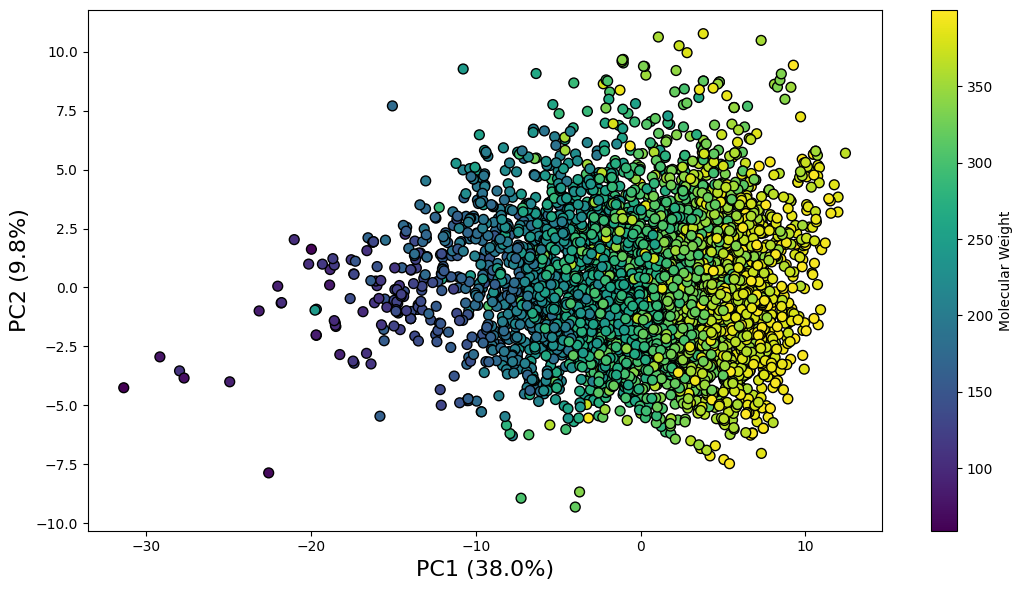

In [ ]:
# 점을 분자량(MW)으로 색칠해 봅니다
plt.figure(figsize=(11, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mordred['MW'], cmap='viridis', s=50, edgecolor='k')
plt.colorbar(sc, label='Molecular Weight')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=16)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=16)
plt.tight_layout()
plt.show()

왼쪽→오른쪽(PC1)으로 갈수록 색(분자량)이 커지는 게 보이나요? **PC1은 사실상 분자량과 거의 같은 방향**입니다. 어떤 디스크립터가 PC1에 가장 크게 기여하는지 확인해 봅니다.

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=X_pca_in.columns, columns=['PC1', 'PC2'])
loadings.abs().sort_values('PC1', ascending=False).head(10)

,PC1,PC2
TMWC10,0.182634,0.037093
SRW04,0.182130,0.016553
MWC02,0.181947,0.024992
MWC03,0.181374,0.016085
SRW06,0.180259,0.013513
MWC04,0.179895,0.003999
SRW02,0.179113,0.056823
nBondsO,0.178503,0.066557
MWC01,0.178503,0.066557
MWC05,0.177001,0.011868


---
# 파트 4. 진짜 물성 예측하기 — 녹는점 QSPR  (~23분)

## 먼저, 너무 쉬운 문제부터

앞에서 만든 디스크립터로 **분자량(MW)** 을 예측해 봅시다. 그런데 디스크립터 안에는 이미 무게 정보가 잔뜩 들어있죠. 그래서 신경망이 거의 완벽하게 맞춥니다.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = (mordred.drop(columns=['MW', 'AMW'])
            .apply(pd.to_numeric, errors='coerce').dropna(axis=1))
y = mordred['MW']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=0.7, random_state=0)

reg = make_pipeline(QuantileTransformer(),
                    MLPRegressor(hidden_layer_sizes=(100, 50, 100),
                                 learning_rate_init=0.01, max_iter=500,
                                 early_stopping=True))
reg.fit(X_tr, y_tr)
y_hat = reg.predict(X_te)
print(f"분자량(MW) 예측 R² = {r2_score(y_te, y_hat):.3f}")

분자량(MW) 예측 R² = 0.991


/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_4350/2049868437.py:6: UserWarning: Glyph 50756 (\N{HANGUL

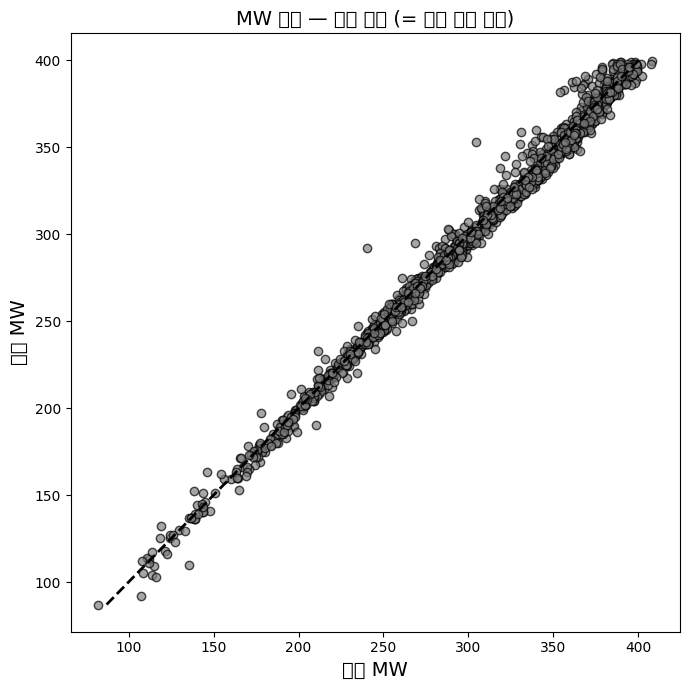

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_hat, y_te, color='gray', edgecolor='black', alpha=0.7)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'k--', lw=2)
plt.xlabel("예측 MW", fontsize=14); plt.ylabel("실제 MW", fontsize=14)
plt.title("MW 예측 — 거의 완벽 (= 너무 쉬운 문제)", fontsize=14)
plt.tight_layout(); plt.show()

R²가 1에 가깝습니다. 하지만 이건 **속임수에 가까운 문제**예요 — 답이 입력 안에 이미 들어 있으니까요.

## 진짜 QSPR — 녹는점(Melting Point)

녹는점은 구조에서 바로 드러나지 않습니다. 분자 모양, 대칭성, 패킹, 수소결합이 복잡하게 얽혀 결정되죠. 이게 **진짜 예측 문제**입니다.

262개 분자에 대해 디스크립터가 미리 계산되어 있는 CSV를 사용합니다. (`6_MP_QSPR.csv` — 같은 폴더에 있거나, 아래에서 내려받습니다.)

In [ ]:
# 파일이 없으면 내려받기
import os
if not os.path.exists("6_MP_QSPR.csv"):
    !wget https://raw.githubusercontent.com/junsookim76/Ewha_2026/main/6_MP_QSPR.csv

data = pd.read_csv("6_MP_QSPR.csv", skiprows=1, sep=",")
print("데이터 shape:", data.shape)
data.head()

--2026-06-10 01:12:27--  https://raw.githubusercontent.com/junsookim76/Ewha_2026/main/6_MP_QSPR.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 291200 (284K) [text/plain]
Saving to: ‘6_MP_QSPR.csv’

6_MP_QSPR.csv       100%[===================>] 284.38K  --.-KB/s    in 0.1s    

2026-06-10 01:12:27 (2.77 MB/s) - ‘6_MP_QSPR.csv’ saved [291200/291200]

데이터 shape: (262, 143)


,Title,Name,SMILES,ALogP,ALogp2,AMR,BCUTw-1l,BCUTw-1h,BCUTc-1l,BCUTc-1h,...,WTPT-1,WTPT-2,WTPT-3,WTPT-4,WTPT-5,WPATH,WPOL,XLogP,Zagreb,mp (°C)
0,Mol1,"1,2,3-trichlorobenzene",C1=CC(=C(C(=C1)Cl)Cl)Cl,2.5095,6.297590,45.1044,11.998562,34.971057,-0.172315,0.143911,...,17.382533,1.931393,7.466759,0.000000,0.0,82,11,2.547,42,52.6
1,Mol2,"1,3,5-trichlorobenzene",C1=C(C=C(C=C1Cl)Cl)Cl,2.5095,6.297590,45.1044,11.998562,34.971057,-0.177867,0.124170,...,17.381716,1.931302,7.483715,0.000000,0.0,84,9,2.547,42,63.4
2,Mol3,11a-hydroxyprogesterone,O=C4\C=C2/[C@]([C@H]1[C@H](O)C[C@@]3(C(C(=O)C)...,0.1509,0.022771,93.4185,11.900000,15.996930,-0.392534,0.206734,...,49.210219,2.050426,7.551241,7.551241,0.0,1149,51,2.741,142,222.0
3,Mol4,17alpha-ethynylestradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)O)CCC4...,1.5135,2.290682,88.3621,11.996151,15.998265,-0.386831,0.131177,...,45.560936,2.070952,5.076087,5.076087,0.0,941,46,3.493,130,235.0
4,Mol5,"3,4-benzopyrene",C1=CC=C2C3=C4C(=CC2=C1)C=CC5=C4C(=CC=C5)C=C3,3.1132,9.692014,93.4252,11.850000,12.150270,-0.182512,0.120933,...,43.297534,2.164877,0.000000,0.000000,0.0,680,40,5.956,120,179.0


앞쪽 3개 열은 식별 정보(번호·이름·SMILES), 마지막 열이 **녹는점(타깃)**, 그 사이가 디스크립터입니다.

> 참고: 이 CSV의 디스크립터 이름(`ALogP`, `BCUT...`)은 파트 2의 Mordred 이름과 다릅니다. 계산 도구가 다를 뿐 개념은 같습니다.

In [ ]:
X = data.iloc[:, 3:-1]      # 디스크립터
y = data.iloc[:, -1:].values  # 녹는점
print("입력 특징 수:", X.shape[1])
X.head()

입력 특징 수: 139


,ALogP,ALogp2,AMR,BCUTw-1l,BCUTw-1h,BCUTc-1l,BCUTc-1h,BCUTp-1l,BCUTp-1h,fragC,...,MW,WTPT-1,WTPT-2,WTPT-3,WTPT-4,WTPT-5,WPATH,WPOL,XLogP,Zagreb
0,2.5095,6.297590,45.1044,11.998562,34.971057,-0.172315,0.143911,6.615496,10.155381,72.03,...,179.930033,17.382533,1.931393,7.466759,0.000000,0.0,82,11,2.547,42
1,2.5095,6.297590,45.1044,11.998562,34.971057,-0.177867,0.124170,6.370548,9.182254,72.03,...,179.930033,17.381716,1.931302,7.483715,0.000000,0.0,84,9,2.547,42
2,0.1509,0.022771,93.4185,11.900000,15.996930,-0.392534,0.206734,4.819646,12.609025,2697.03,...,330.219495,49.210219,2.050426,7.551241,7.551241,0.0,1149,51,2.741,142
3,1.5135,2.290682,88.3621,11.996151,15.998265,-0.386831,0.131177,5.036036,12.015619,1939.02,...,296.177630,45.560936,2.070952,5.076087,5.076087,0.0,941,46,3.493,130
4,3.1132,9.692014,93.4252,11.850000,12.150270,-0.182512,0.120933,7.210065,11.609920,916.00,...,252.093900,43.297534,2.164877,0.000000,0.000000,0.0,680,40,5.956,120


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

이제 **Keras로 직접 신경망을 쌓습니다.** 여러분이 아는 그 MLP입니다 — 입력층, 은닉층 몇 개(ReLU), 출력 노드 1개(녹는점).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1))                      # 출력: 녹는점 1개
model.summary()

model.compile(optimizer='adam', loss='mean_absolute_error')

# 검증 손실이 20에폭 동안 안 좋아지면 자동 중단 + 최적 모델 저장
early_stop  = EarlyStopping(monitor='val_loss', patience=20)
checkpoint  = ModelCheckpoint(filepath="./MP_best.keras", monitor='val_loss',
                              verbose=0, save_best_only=True)

history = model.fit(X_train, y_train, validation_split=0.25,
                    epochs=1000, batch_size=20,
                    callbacks=[early_stop, checkpoint])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 109.1779 - val_loss: 100.3741
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 93.3731 - val_loss: 101.2420
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 84.3769 - val_loss: 91.0156
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 80.7173 - val_loss: 89.0605
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 76.3329 - val_loss: 86.7198
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 75.7469 - val_loss: 83.5897
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 71.2122 - val_loss: 83.6950
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 66.5980 - val_loss: 77.5255
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 65.4934 - val_loss: 79.3241
Epoch 10/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 65.2824 - val_loss: 73.4906
Epoch 11/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 62.2938 - val_loss: 73.2484
Epoch 12/1000
8/8 ━━━━━━━━━━━━━━━━━━━━

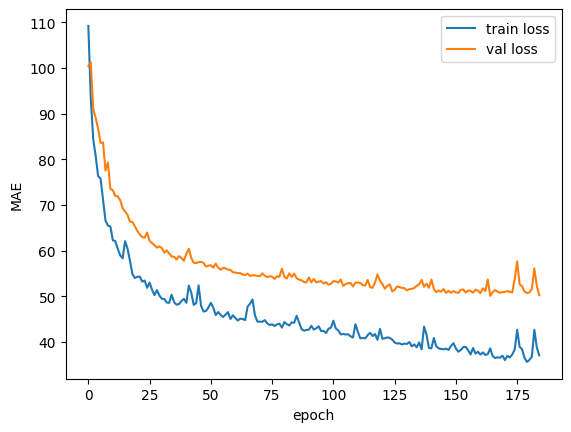

In [ ]:
# 학습 곡선
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch'); plt.ylabel('MAE'); plt.legend(); plt.show()

In [ ]:
# 테스트셋 일부의 실제값 vs 예측값
Y_pred = model.predict(X_test).flatten()
for i in range(15):
    print(f"실제 녹는점: {y_test[i][0]:7.2f}   예측: {Y_pred[i]:7.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
실제 녹는점:  225.00   예측:  212.23
실제 녹는점:  186.10   예측:  137.29
실제 녹는점:  238.00   예측:  227.45
실제 녹는점:  278.00   예측:  156.87
실제 녹는점:  190.00   예측:  163.20
실제 녹는점:  148.70   예측:  154.74
실제 녹는점:  172.50   예측:  155.82
실제 녹는점:  160.00   예측:  153.09
실제 녹는점:  213.00   예측:  175.80
실제 녹는점:  199.00   예측:  151.94
실제 녹는점:  265.00   예측:  210.79
실제 녹는점:   91.50   예측:   93.72
실제 녹는점:  230.00   예측:  181.76
실제 녹는점:  153.80   예측:  167.20
실제 녹는점:  169.80   예측:  137.45


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


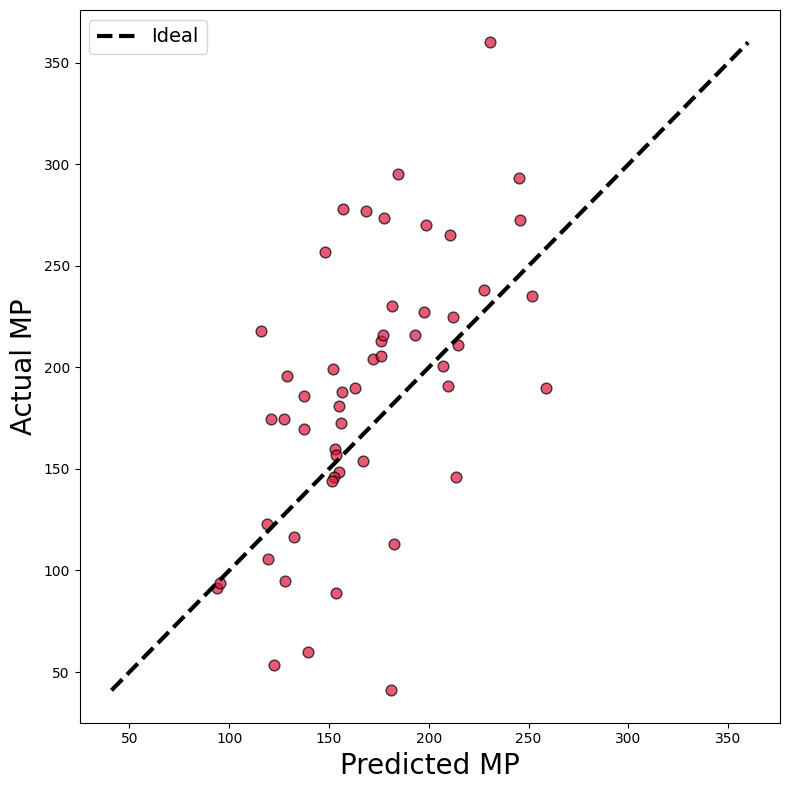

In [ ]:
# 패리티 플롯 (대각선에 가까울수록 좋음)
y_pred = model.predict(X_test)
plt.figure(figsize=(8, 8))
plt.scatter(y_pred, y_test, color='crimson', edgecolor='black', alpha=0.7, s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, label='Ideal')
plt.xlabel("Predicted MP", fontsize=20); plt.ylabel("Actual MP", fontsize=20)
plt.legend(fontsize=14); plt.tight_layout(); plt.show()

In [ ]:
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²   of MP = {r2:.3f}")
print(f"RMSE of MP = {rmse:.2f}")

R²   of MP = 0.263
RMSE of MP = 57.70


## 두 문제를 비교해 봅시다

| 타깃 | R² | 의미 |
|------|----|------|
| 분자량 (MW) | ≈ 1.0 | 답이 입력에 이미 있음 — 사실상 공짜 |
| 녹는점 (MP) | 훨씬 낮음 | 구조에서 물성을 *진짜로* 추론해야 함 |

녹는점 예측이 완벽하지 않다는 사실이 바로 QSPR이 흥미로운 연구 주제인 이유입니다. 점들이 대각선 주변에 흩어진 정도가 모델이 아직 못 잡은 물리를 보여줍니다.

---
# 마무리 & 다음 단계  (~5분)

오늘 우리는 **"분자를 숫자로 바꿔 신경망에 먹이는"** 전 과정을 한 바퀴 돌았습니다.

1. **표현** — SMILES로 분자를 불러오고 2D/3D로 시각화
2. **특징화** — 구조를 디스크립터(숫자 벡터)로 변환
3. **탐색** — 상관분석과 PCA로 특징 공간 이해
4. **예측** — 신경망으로 실제 물성(녹는점) QSPR

**한계와 그다음:** 디스크립터 방식은 "분자를 사람이 정한 숫자 요약으로 압축"합니다. 이 과정에서 정보가 손실되죠. 최신 접근은 분자를 **그래프 그대로** 신경망에 넣는 **그래프 신경망(Graph Neural Network)** 으로, 디스크립터를 손으로 고르는 단계를 모델이 스스로 학습합니다. 그것이 다음 강의의 자연스러운 출발점입니다.

> **복습 과제 아이디어:** 은닉층 구조나 디스크립터 종류를 바꿔가며 녹는점 예측 R²가 어떻게 변하는지 실험해 보세요.
